In [2]:
import os
for item in os.listdir("/content/"):
  print(item)

.config
Copy of devnagari digit.zip
sample_data


In [3]:
import zipfile

with zipfile.ZipFile("/content/Copy of devnagari digit.zip", "r") as zip_ref:
    zip_ref.extractall("/content/dataset")

print("Unzipped successfully!")

Unzipped successfully!


In [4]:
!ls /content/dataset

DevanagariHandwrittenDigitDataset


In [5]:
!ls /content/dataset/DevanagariHandwrittenDigitDataset

Test  Train


In [6]:
!ls /content/dataset/DevanagariHandwrittenDigitDataset/Train

digit_0  digit_2  digit_4  digit_6  digit_8
digit_1  digit_3  digit_5  digit_7  digit_9


training data
Found classes: ['digit_0', 'digit_1', 'digit_2', 'digit_3', 'digit_4', 'digit_5', 'digit_6', 'digit_7', 'digit_8', 'digit_9']

testing data
Found classes: ['digit_0', 'digit_1', 'digit_2', 'digit_3', 'digit_4', 'digit_5', 'digit_6', 'digit_7', 'digit_8', 'digit_9']


 Training images shape : (17000, 784)
 Training labels shape : (17000, 10)
 Testing images shape  : (3000, 784)
 Testing labels shape  : (3000, 10)


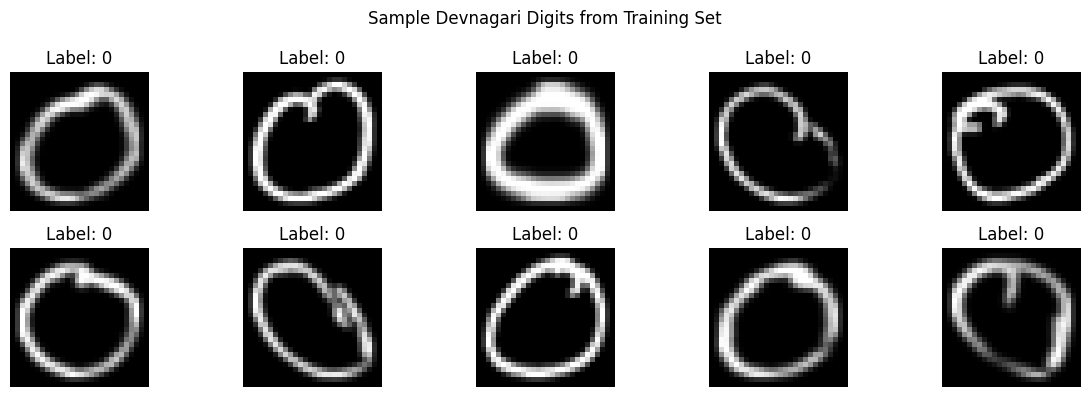

In [7]:
import os
import numpy as np
from PIL import Image
from tensorflow.keras.utils import to_categorical
import matplotlib.pyplot as plt

train_dir = "/content/dataset/DevanagariHandwrittenDigitDataset/Train/"
test_dir  = "/content/dataset/DevanagariHandwrittenDigitDataset/Test/"

img_height = 28
img_width  = 28

def load_images_from_folder(folder):
    images = []
    labels = []

    class_names = sorted(os.listdir(folder))
    class_map = {name: i for i, name in enumerate(class_names)}

    print(f"Found classes: {class_names}\n")

    for class_name in class_names:
        class_path = os.path.join(folder, class_name)
        label = class_map[class_name]

        for filename in os.listdir(class_path):
            img_path = os.path.join(class_path, filename)

            img = Image.open(img_path).convert("L")
            img = img.resize((img_width, img_height))
            img = np.array(img) / 255.0

            images.append(img)
            labels.append(label)

    return np.array(images), np.array(labels)

print("training data")
x_train, y_train = load_images_from_folder(train_dir)

print("testing data")
x_test, y_test = load_images_from_folder(test_dir)

x_train = x_train.reshape(-1, img_height * img_width)
x_test  = x_test.reshape(-1, img_height * img_width)

y_train = to_categorical(y_train, num_classes=10)
y_test  = to_categorical(y_test,  num_classes=10)

print(f"\n Training images shape : {x_train.shape}")
print(f" Training labels shape : {y_train.shape}")
print(f" Testing images shape  : {x_test.shape}")
print(f" Testing labels shape  : {y_test.shape}")

plt.figure(figsize=(12, 4))
for i in range(10):
    plt.subplot(2, 5, i + 1)
    plt.imshow(x_train[i].reshape(28, 28), cmap='gray')
    plt.title(f"Label: {np.argmax(y_train[i])}")
    plt.axis("off")

plt.suptitle("Sample Devnagari Digits from Training Set")
plt.tight_layout()
plt.show()

In [8]:
import tensorflow as tf
from tensorflow import keras

num_classes = 10

model = keras.Sequential([
    keras.layers.Input(shape=(784,)),
    keras.layers.Dense(64, activation="sigmoid"),
    keras.layers.Dense(128, activation="sigmoid"),
    keras.layers.Dense(256, activation="sigmoid"),
    keras.layers.Dense(num_classes, activation="softmax"),
])

model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 64)             │        50,240 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 128)            │         8,320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 256)            │        33,024 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 10)             │         2,570 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 94,154 (367.79 KB)

 Trainable params: 94,154 (367.79 KB)

 Non-trainable params: 0 (0.00 B)

In [9]:
model.compile(
    optimizer="adam",
    loss="categorical_crossentropy",
    metrics=["accuracy"]
)

print(" Model compiled successfully")


 Model compiled successfully


Epoch 1/20
107/107 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - accuracy: 0.3002 - loss: 2.0195
Epoch 1: val_loss improved from None to 6.69120, saving model to best_model.keras

Epoch 1: finished saving model to best_model.keras
107/107 ━━━━━━━━━━━━━━━━━━━━ 5s 20ms/step - accuracy: 0.4916 - loss: 1.6442 - val_accuracy: 0.0000e+00 - val_loss: 6.6912
Epoch 2/20
106/107 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.8215 - loss: 0.6240
Epoch 2: val_loss did not improve from 6.69120
107/107 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.8518 - loss: 0.4987 - val_accuracy: 0.0000e+00 - val_loss: 7.7845
Epoch 2: early stopping
 Model trained successfully!


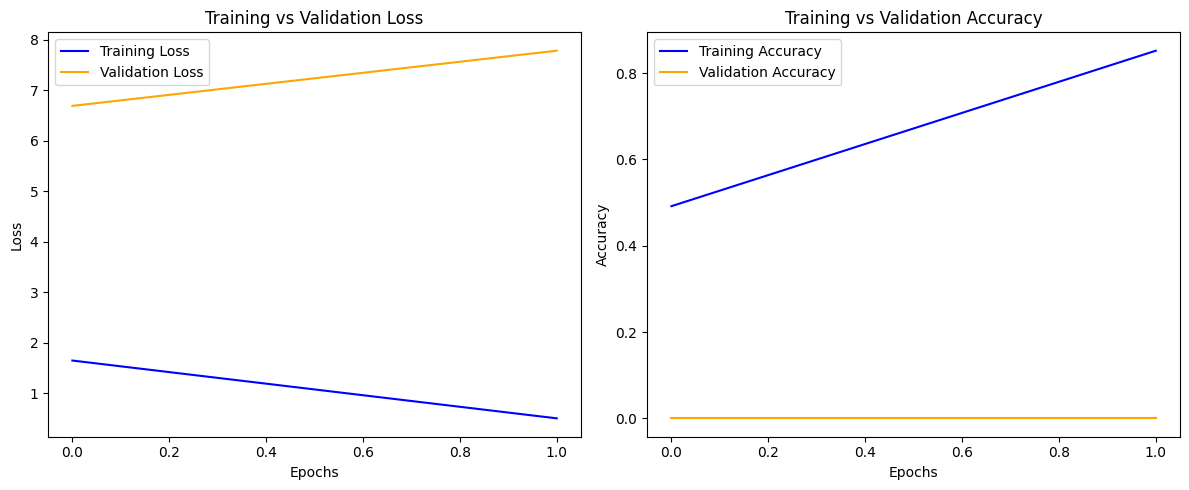

In [10]:
callbacks = [

    keras.callbacks.ModelCheckpoint(
        filepath="best_model.keras",
        save_best_only=True,
        verbose=1
    ),

    keras.callbacks.EarlyStopping(
        monitor="val_loss",
        verbose=1
    ),
]


history = model.fit(
    x_train,
    y_train,
    batch_size=128,
    epochs=20,
    validation_split=0.2,
    callbacks=callbacks,
    verbose=1
)

print(" Model trained successfully!")


import matplotlib.pyplot as plt

train_loss = history.history['loss']
val_loss   = history.history['val_loss']
train_acc  = history.history['accuracy']
val_acc    = history.history['val_accuracy']

plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
plt.plot(train_loss, label='Training Loss',   color='blue')
plt.plot(val_loss,   label='Validation Loss', color='orange')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.title('Training vs Validation Loss')
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(train_acc, label='Training Accuracy',   color='blue')
plt.plot(val_acc,   label='Validation Accuracy', color='orange')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.title('Training vs Validation Accuracy')
plt.legend()

plt.tight_layout()
plt.show()


In [12]:
test_loss, test_acc = model.evaluate(x_test, y_test, verbose=2)
print(f"\nTest Loss     : {test_loss:.4f}")
print(f"Test Accuracy : {test_acc:.4f} ({test_acc*100:.2f}%)")

94/94 - 0s - 3ms/step - accuracy: 0.7200 - loss: 1.8203

Test Loss     : 1.8203
Test Accuracy : 0.7200 (72.00%)


In [14]:
model.save("devnagari_model.h5")
print("Model saved as devnagari_model.h5")

import tensorflow as tf
loaded_model = tf.keras.models.load_model("devnagari_model.h5")
print("Model loaded successfully!")


loaded_loss, loaded_acc = loaded_model.evaluate(x_test, y_test, verbose=2)
print(f"\nLoaded Model Test Loss     : {loaded_loss:.4f}")
print(f"Loaded Model Test Accuracy : {loaded_acc:.4f} ({loaded_acc*100:.2f}%)")

Model saved as devnagari_model.h5
Model loaded successfully!
94/94 - 1s - 12ms/step - accuracy: 0.7200 - loss: 1.8203

Loaded Model Test Loss     : 1.8203
Loaded Model Test Accuracy : 0.7200 (72.00%)


In [20]:
import numpy as np

# Make predictions on all test images
predictions = model.predict(x_test)
predicted_labels = np.argmax(predictions, axis=1)
true_labels      = np.argmax(y_test, axis=1)

# Count correct and incorrect
correct   = np.sum(predicted_labels == true_labels)
incorrect = np.sum(predicted_labels != true_labels)
total     = len(true_labels)

print(f"Total Images : {total}")
print(f"Correct   : {correct}")
print(f"Incorrect : {incorrect}")
print(f"Accuracy  : {correct/total*100:.2f}%")

94/94 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step
Total Images : 3000
Correct   : 2160
Incorrect : 840
Accuracy  : 72.00%
